# Student Clustering: Gaming Behavior and Academic Performance

**Goal:** group students into behavior types using only their gaming and study habits,
then check what those groups mean for their grades.

We use two clustering algorithms — **K-Means** and **DBSCAN** — and compare them.

## 1. The dataset and the goal

The data has 8,000 students. Each row is one student, with numeric columns such as gaming
hours, study hours, device usage, addiction score, and final grades.

**Analysis goal:** find natural groups of students based on *behavior only*
(how they spend their time). Grades are kept out of the clustering on purpose, so we can
use grades afterwards as an honest check: do the behavior groups actually differ in results?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("Gaming_Academic_Performance.csv")
print("rows, columns:", df.shape)
df.head()

rows, columns: (8000, 14)


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


## 2. Preprocessing

Three small steps:

1. Pick the four behavior features we cluster on.
2. Check missing values (the dataset is already clean, so this is just a confirmation).
3. **Scale** the features — this one is not optional. Gaming hours go up to 8 while
   device usage goes up to ~14 and reaction time is in the hundreds. Both K-Means and
   DBSCAN measure distance, so an unscaled column would dominate the result.

In [2]:
# Behavior features used for clustering (grades are deliberately excluded).
features = ["gaming_hours", "study_hours", "device_usage", "addiction_score"]

# Confirm there is nothing missing before we scale.
print("Missing values per column:")
print(df[features + ["grades"]].isna().sum())

Missing values per column:
gaming_hours       0
study_hours        0
device_usage       0
addiction_score    0
grades             0
dtype: int64


In [3]:
# Original scales are very different -> scaling is needed.
df[features].describe().loc[["mean", "std", "min", "max"]].round(2)

,gaming_hours,study_hours,device_usage,addiction_score
mean,4.09,5.46,7.59,9.91
std,2.31,2.58,2.71,5.04
min,0.00,1.00,1.10,-4.51
max,8.00,10.00,13.95,23.16


In [4]:
# Standardize: every feature becomes mean 0 and standard deviation 1.
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

X_scaled = pd.DataFrame(X, columns=features)
X_scaled.describe().loc[["mean", "std", "min", "max"]].round(2)

,gaming_hours,study_hours,device_usage,addiction_score
mean,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.77,-1.73,-2.39,-2.86
max,1.70,1.76,2.35,2.63


Every feature now has mean 0 and standard deviation 1, so no single column can dominate
the distance calculation.

## 3. Algorithm 1 — K-Means

K-Means needs the number of clusters up front, so we test k from 2 to 8 with two checks:

- **Elbow:** how much the total within-cluster distance drops as k grows.
- **Silhouette:** how well separated the clusters are (higher is better, max is 1).

In [5]:
k_values = range(2, 9)
inertia = []
silhouette = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, labels))

pd.DataFrame({"k": list(k_values), "inertia": np.round(inertia), "silhouette": np.round(silhouette, 3)})

,k,inertia,silhouette
0,2,15998.0,0.408
1,3,12707.0,0.339
2,4,9997.0,0.302
3,5,8182.0,0.305
4,6,6948.0,0.292
5,7,6289.0,0.277
6,8,5758.0,0.256


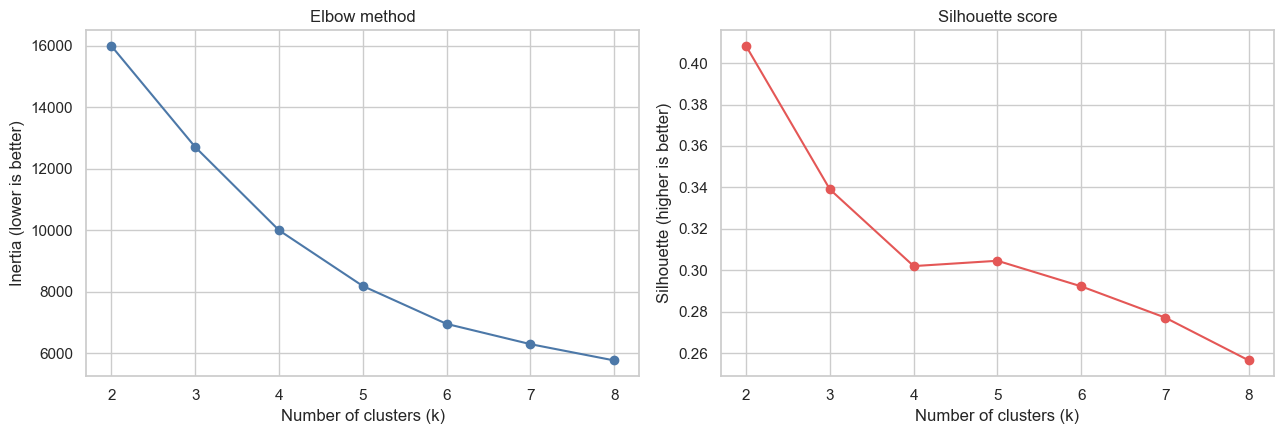

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_values), inertia, marker="o", color="#4C78A8")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (lower is better)")

axes[1].plot(list(k_values), silhouette, marker="o", color="#E45756")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette (higher is better)")

plt.tight_layout()
plt.show()

k = 2 has the highest silhouette, but it only splits students into "games a lot" and
"games a little". **k = 3** scores almost as well and gives a much more useful split,
because it separates the heavy gamers who still study from the ones who do not.
We continue with k = 3.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X)

print("Students per cluster:")
print(df["kmeans_cluster"].value_counts().sort_index())

Students per cluster:
kmeans_cluster
0    3512
1    2354
2    2134
Name: count, dtype: int64


## 4. Algorithm 2 — DBSCAN

DBSCAN does not need the number of clusters, but it needs `eps` (the neighborhood radius)
and `min_samples`. We use `min_samples = 8` (twice the number of features) and pick `eps`
from the k-distance plot: the distance to the 8th nearest neighbor, sorted. The "elbow"
of that curve is a good starting value.

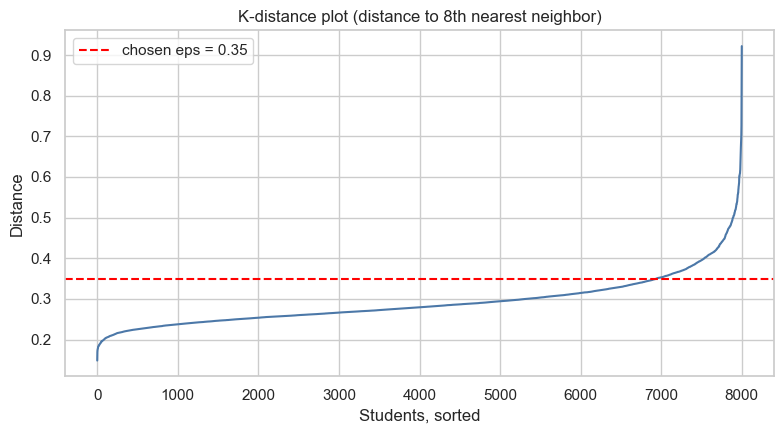

In [8]:
neighbors = NearestNeighbors(n_neighbors=8).fit(X)
distances = np.sort(neighbors.kneighbors(X)[0][:, -1])

plt.figure(figsize=(8, 4.5))
plt.plot(distances, color="#4C78A8")
plt.axhline(0.35, color="red", linestyle="--", label="chosen eps = 0.35")
plt.title("K-distance plot (distance to 8th nearest neighbor)")
plt.xlabel("Students, sorted")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Try a few eps values before deciding.
rows = []
for eps in [0.25, 0.30, 0.35, 0.40, 0.50]:
    labels = DBSCAN(eps=eps, min_samples=8).fit_predict(X)
    n_clusters = len(set(labels) - {-1})
    rows.append({
        "eps": eps,
        "clusters found": n_clusters,
        "noise points": int((labels == -1).sum()),
        "noise %": round((labels == -1).mean() * 100, 1),
    })

pd.DataFrame(rows)

,eps,clusters found,noise points,noise %
0,0.25,89,3465,43.3
1,0.30,2,838,10.5
2,0.35,1,245,3.1
3,0.40,1,84,1.0
4,0.50,1,10,0.1


Small `eps` breaks the data into dozens of tiny fragments, and larger `eps` swallows
everything into one cluster. At `eps = 0.35` the result is stable: **one big cluster plus
a small group of unusual students** marked as noise (label `-1`).

In [10]:
dbscan = DBSCAN(eps=0.35, min_samples=8)
df["dbscan_cluster"] = dbscan.fit_predict(X)

print("DBSCAN result (-1 means noise / unusual student):")
print(df["dbscan_cluster"].value_counts())

DBSCAN result (-1 means noise / unusual student):
dbscan_cluster
 0    7755
-1     245
Name: count, dtype: int64


## 5. Evaluation

We evaluate in two ways: the **silhouette score** (a number) and a **2D picture** of the
data using PCA, which compresses the four features into two axes so we can actually see
the clusters.

In [11]:
kmeans_sil = silhouette_score(X, df["kmeans_cluster"])

# DBSCAN found only one real cluster, so a silhouette score cannot be computed for it.
real_dbscan_clusters = len(set(df["dbscan_cluster"]) - {-1})

comparison = pd.DataFrame({
    "Algorithm": ["K-Means (k=3)", "DBSCAN (eps=0.35)"],
    "Clusters found": [3, real_dbscan_clusters],
    "Noise points": [0, int((df["dbscan_cluster"] == -1).sum())],
    "Silhouette score": [round(kmeans_sil, 3), "not defined (only 1 cluster)"],
})
comparison

,Algorithm,Clusters found,Noise points,Silhouette score
0,K-Means (k=3),3,0,0.339
1,DBSCAN (eps=0.35),1,245,not defined (only 1 cluster)


Information kept by the 2 axes: 93.4 %


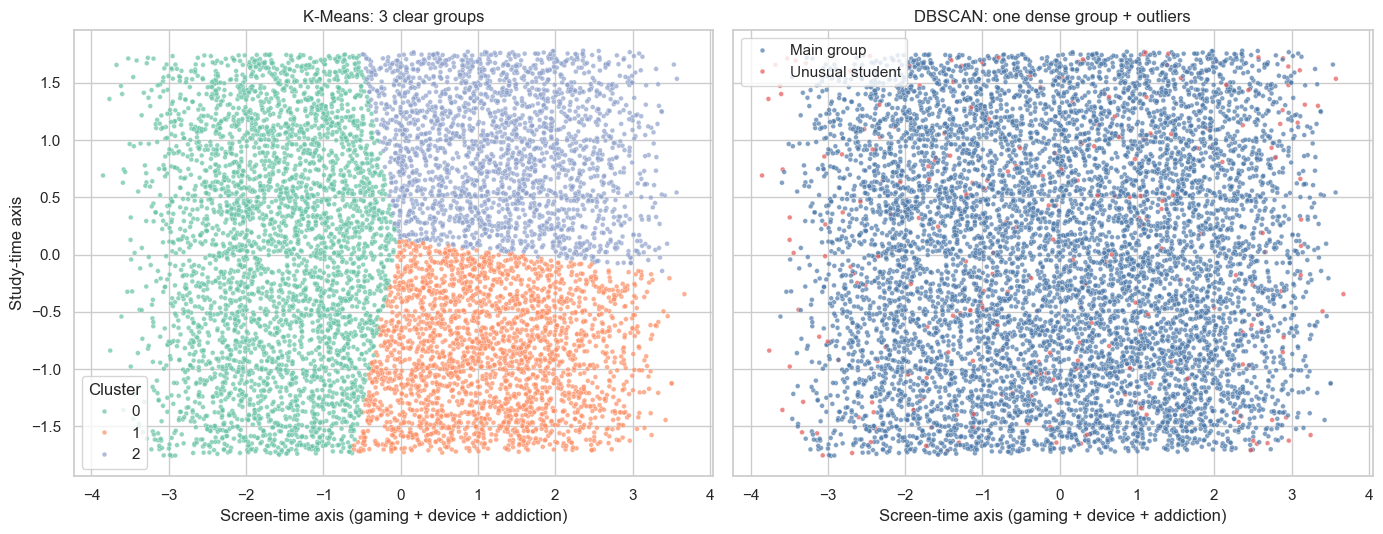

In [12]:
# Compress the 4 scaled features into 2 axes so we can see the clusters.
pca = PCA(n_components=2, random_state=42)
points = pca.fit_transform(X)
df["pca1"], df["pca2"] = points[:, 0], points[:, 1]

print("Information kept by the 2 axes:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

sns.scatterplot(data=df, x="pca1", y="pca2", hue="kmeans_cluster",
                palette="Set2", s=12, alpha=0.7, ax=axes[0])
axes[0].set_title("K-Means: 3 clear groups")
axes[0].legend(title="Cluster")

sns.scatterplot(data=df, x="pca1", y="pca2", hue=df["dbscan_cluster"].map({-1: "Unusual student", 0: "Main group"}),
                palette={"Main group": "#4C78A8", "Unusual student": "#E45756"}, s=12, alpha=0.7, ax=axes[1])
axes[1].set_title("DBSCAN: one dense group + outliers")
axes[1].legend(title="")

for ax in axes:
    ax.set_xlabel("Screen-time axis (gaming + device + addiction)")
axes[0].set_ylabel("Study-time axis")

plt.tight_layout()
plt.show()

**What the picture says:** the students form one continuous cloud with no empty gaps
inside it. K-Means cuts that cloud into three sensible regions. DBSCAN, which only creates
a new cluster when it finds an empty gap, refuses to split it and instead flags the 245
students on the outer edge as unusual.

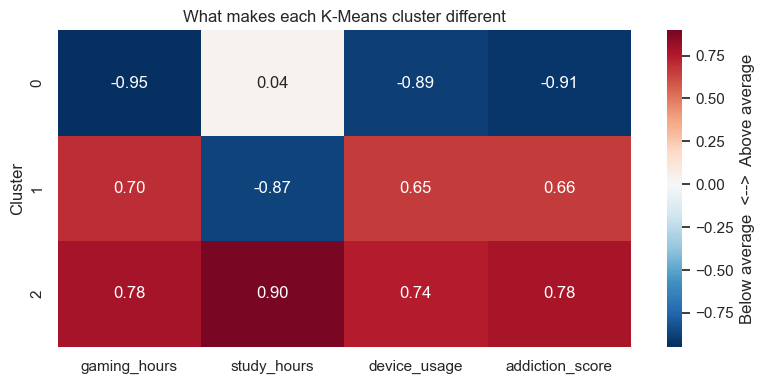

In [13]:
# How different is each cluster from the average student?
profile_z = df.groupby("kmeans_cluster")[features].mean()
profile_z = (profile_z - df[features].mean()) / df[features].std()

plt.figure(figsize=(8, 4))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Below average  <-->  Above average"})
plt.title("What makes each K-Means cluster different")
plt.xlabel("")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

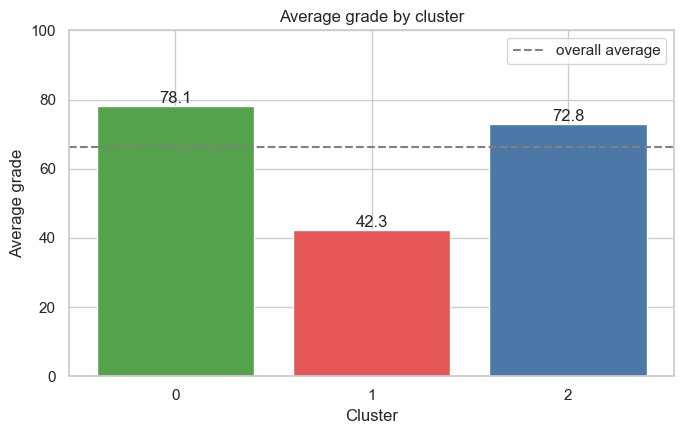

In [14]:
# The real test: do the behavior groups differ in grades?
grade_means = df.groupby("kmeans_cluster")["grades"].mean().round(1)

plt.figure(figsize=(7, 4.5))
bars = plt.bar(grade_means.index.astype(str), grade_means.values, color=["#54A24B", "#E45756", "#4C78A8"])
plt.bar_label(bars, fmt="%.1f")
plt.axhline(df["grades"].mean(), color="gray", linestyle="--", label="overall average")
plt.title("Average grade by cluster")
plt.xlabel("Cluster")
plt.ylabel("Average grade")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Interpretation — who is in each cluster?

Grades were never used to build the clusters, yet the three groups end up with very
different grades. That is the strongest sign that the clustering found something real.

In [15]:
profile = df.groupby("kmeans_cluster").agg(
    students=("student_id", "count"),
    gaming_hours=("gaming_hours", "mean"),
    study_hours=("study_hours", "mean"),
    device_usage=("device_usage", "mean"),
    addiction_score=("addiction_score", "mean"),
    sleep_hours=("sleep_hours", "mean"),
    attendance=("attendance", "mean"),
    average_grade=("grades", "mean"),
).round(2)

profile["name"] = ["Balanced students", "At-risk gamers", "Heavy-load gamers"]
profile

,students,gaming_hours,study_hours,device_usage,addiction_score,sleep_hours,attendance,average_grade,name
kmeans_cluster,,,,,,,,,
0,3512,1.9,5.56,5.18,5.31,6.47,79.91,78.15,Balanced students
1,2354,5.7,3.22,9.36,13.22,6.48,80.17,42.34,At-risk gamers
2,2134,5.9,7.77,9.59,13.82,6.55,79.54,72.78,Heavy-load gamers


**Cluster 0 — "Balanced students" (3,512 students, average grade 78)**
Light gaming (~1.9 h), normal study time (~5.6 h), low addiction score. This is the healthy
baseline group and it has the best grades.

**Cluster 1 — "At-risk gamers" (2,354 students, average grade 42)**
Heavy gaming (~5.7 h) *combined with* the lowest study time (~3.2 h) and the highest
addiction score. Their grades are around 42 — roughly 36 points below the balanced group.
This is the group that needs help.

**Cluster 2 — "Heavy-load gamers" (2,134 students, average grade 73)**
They game just as much as Cluster 1 (~5.9 h) and score just as high on addiction, but they
still study ~7.8 hours. Their grades stay near 73, close to the balanced group.

**The key finding:** gaming hours alone do not predict a bad outcome. Clusters 1 and 2
game the same amount, but only the one that stopped studying is failing. The thing that
separates them is **study time, not gaming time**.

### How this can be used in the real world

1. **Early-warning screening.** A university or school can score every student with the
   saved `scaler` and `kmeans` model and get a cluster label in one line of code. Students
   landing in Cluster 1 are flagged for an advisor meeting *before* exam results arrive,
   instead of after they fail.

2. **Give each group a different message.** Telling all gamers to "play less" is wasted
   effort — Cluster 2 games heavily and still does fine. Cluster 1 needs a *study-time*
   plan (a fixed daily study block), Cluster 2 needs sleep and workload monitoring, and
   Cluster 0 needs nothing at all. Same budget, better targeting.

3. **Measure whether a program works.** Run the clustering again next semester. If a
   support program is effective, the number of students in Cluster 1 should go down and
   Cluster 0 should grow. That is a concrete, trackable KPI.

4. **Product side (game studios / ed-tech apps).** The same three profiles map to product
   decisions: healthy-play reminders and session limits for the Cluster 1 pattern, and
   study-mode or scheduling features for Cluster 2 users who are trying to balance both.

5. **Manual review of the 245 DBSCAN outliers.** These are students whose habit combination
   does not match anyone else. They are exactly the cases where an automatic rule would give
   the wrong answer, so they should be reviewed by a human rather than by the model.

## 7. Insights and recommendation

**Which algorithm won: K-Means.**

- K-Means found 3 clean, meaningful groups with a silhouette score of 0.34.
- DBSCAN found only 1 cluster and labelled 245 students (3%) as unusual. It is not a
  failure — it is telling us the truth: student behavior is a smooth, continuous cloud
  with no natural empty gaps between groups. DBSCAN needs those gaps; K-Means does not.
- **Recommendation:** use **K-Means with k = 3** for grouping students, and keep DBSCAN as
  a side tool for spotting unusual students who need a manual look.

**What we learned about the students:**

1. Students split into three behavior types: balanced (44%), at-risk gamers (29%), and
   heavy-load gamers (27%).
2. The at-risk group averages **42** in grades, while the balanced group averages **78** —
   a gap of about 36 points.
3. Gaming by itself is not the problem. Clusters 1 and 2 game almost exactly the same
   number of hours, but Cluster 2 keeps studying and keeps its grades near 73.
4. **Study time is the deciding factor.** The real warning sign is *heavy gaming plus low
   study hours together*, not gaming on its own.
5. Because we never let the model see grades, the grade gap between clusters is real
   evidence that these behavior groups matter — not something we built into the result.

**One-line takeaway:** don't ask students how much they play, ask how much they study —
and only worry about the gamers whose study time has dropped.